1. ỨNG DỤNG DEMO K-MEANS (GOM CỤM HOA)


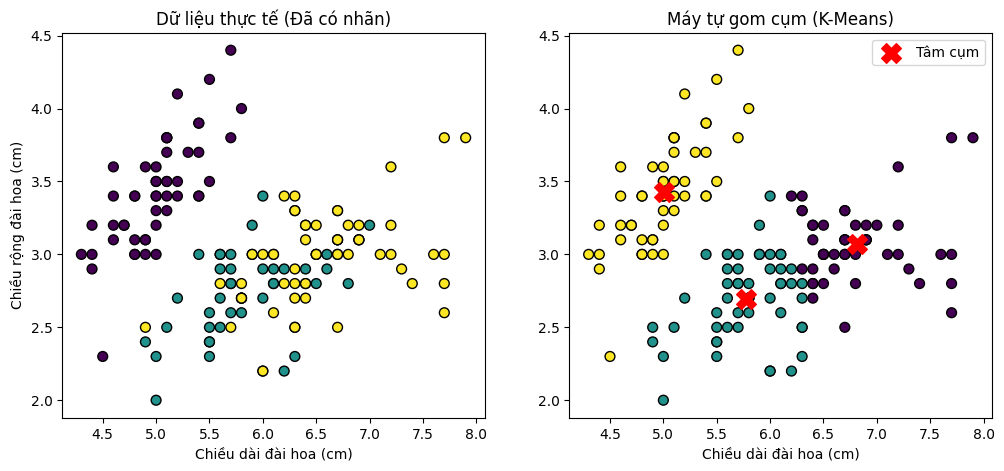


2. ỨNG DỤNG DEMO K-NN (PHÂN LOẠI HOA)
[Hệ thống] Đang huấn luyện mô hình K-NN...
[Kết quả] Độ chính xác của mô hình: 80.00%


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

# Bỏ qua các cảnh báo lặt vặt của thư viện để output gọn gàng
warnings.filterwarnings('ignore')

# ==========================================
# KHỞI TẠO DỮ LIỆU THỰC TẾ (IRIS DATASET)
# ==========================================
# Load bộ dữ liệu hoa Iris (gồm 3 loại: setosa, versicolor, virginica)
iris = datasets.load_iris()
# Chỉ lấy 2 đặc trưng đầu (Chiều dài và chiều rộng đài hoa) để vẽ đồ thị 2D cho dễ nhìn
X = iris.data[:, :2]
y = iris.target

# ==========================================
# 1. ỨNG DỤNG DEMO K-MEANS
# ==========================================
def demo_kmeans():
    print("="*50)
    print("1. ỨNG DỤNG DEMO K-MEANS (GOM CỤM HOA)")
    print("="*50)

    # Giả sử ta chưa biết nhãn, ép máy tự chia dữ liệu thành 3 cụm
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)

    # Vẽ đồ thị so sánh thực tế và kết quả máy tự gom cụm
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title('Dữ liệu thực tế (Đã có nhãn)')
    plt.xlabel('Chiều dài đài hoa (cm)')
    plt.ylabel('Chiều rộng đài hoa (cm)')

    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', edgecolor='k', s=50)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Tâm cụm')
    plt.title('Máy tự gom cụm (K-Means)')
    plt.xlabel('Chiều dài đài hoa (cm)')
    plt.legend()
    plt.show()

# ==========================================
# 2. ỨNG DỤNG DEMO K-NN
# ==========================================
def demo_knn():
    print("\n" + "="*50)
    print("2. ỨNG DỤNG DEMO K-NN (PHÂN LOẠI HOA)")
    print("="*50)

    # Chia tập dữ liệu: 80% để học (train), 20% để thi thử (test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Khởi tạo mô hình K-NN với số láng giềng k = 5
    knn = KNeighborsClassifier(n_neighbors=5)

    # Máy bắt đầu học
    print("[Hệ thống] Đang huấn luyện mô hình K-NN...")
    knn.fit(X_train, y_train)

    # Dự đoán trên tập kiểm tra
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"[Kết quả] Độ chính xác của mô hình: {acc*100:.2f}%")

# Chạy demo
demo_kmeans()
demo_knn()